# Snoring Detection (Kaggle) — CNN on Mel-Spectrograms (1-second clips)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CELL 1 — Upload your downloaded Kaggle dataset
# Run this cell first

from google.colab import files
import zipfile
import os

# Path to your zip file in Google Drive
zip_path = "/content/drive/MyDrive/Colab Notebooks/Snoring/snoring.zip"   # change if needed

# Extract location
extract_path = "/content/snoring_dataset"

# Create folder if not exists
os.makedirs(extract_path, exist_ok=True)

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

# Check extracted files
for root, dirs, files in os.walk(extract_path):
    for file in files[:10]:  # show first 10 files
        print(os.path.join(root, file))

✅ Dataset extracted successfully!
/content/snoring_dataset/Snoring Dataset/Snoring_dataset.txt
/content/snoring_dataset/Snoring Dataset/0/0_338.wav
/content/snoring_dataset/Snoring Dataset/0/0_253.wav
/content/snoring_dataset/Snoring Dataset/0/0_389.wav
/content/snoring_dataset/Snoring Dataset/0/0_115.wav
/content/snoring_dataset/Snoring Dataset/0/0_78.wav
/content/snoring_dataset/Snoring Dataset/0/0_158.wav
/content/snoring_dataset/Snoring Dataset/0/0_80.wav
/content/snoring_dataset/Snoring Dataset/0/0_336.wav
/content/snoring_dataset/Snoring Dataset/0/0_441.wav
/content/snoring_dataset/Snoring Dataset/0/0_346.wav
/content/snoring_dataset/Snoring Dataset/1/1_300.wav
/content/snoring_dataset/Snoring Dataset/1/1_120.wav
/content/snoring_dataset/Snoring Dataset/1/1_197.wav
/content/snoring_dataset/Snoring Dataset/1/1_29.wav
/content/snoring_dataset/Snoring Dataset/1/1_371.wav
/content/snoring_dataset/Snoring Dataset/1/1_285.wav
/content/snoring_dataset/Snoring Dataset/1/1_128.wav
/conten

In [ ]:
# CELL 2 — Install libraries
!pip install librosa scikit-learn tensorflow numpy pandas matplotlib seaborn resampy

import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries installed and imported")

✅ Libraries installed and imported


In [ ]:
# CELL 3 — Understand dataset structure

import os

dataset_path = '/content/snoring_dataset'

# Find all audio files
audio_files = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.wav', '.mp3', '.ogg')):
            audio_files.append(os.path.join(root, file))

print(f"Total audio files found: {len(audio_files)}")
print("\nFirst 10 files:")
for f in audio_files[:10]:
    print(f)

# Check folder structure
print("\nFolder structure:")
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        count = len(os.listdir(item_path))
        print(f"  📁 {item}/ ({count} files)")

Total audio files found: 1000

First 10 files:
/content/snoring_dataset/Snoring Dataset/0/0_338.wav
/content/snoring_dataset/Snoring Dataset/0/0_253.wav
/content/snoring_dataset/Snoring Dataset/0/0_389.wav
/content/snoring_dataset/Snoring Dataset/0/0_115.wav
/content/snoring_dataset/Snoring Dataset/0/0_78.wav
/content/snoring_dataset/Snoring Dataset/0/0_158.wav
/content/snoring_dataset/Snoring Dataset/0/0_80.wav
/content/snoring_dataset/Snoring Dataset/0/0_336.wav
/content/snoring_dataset/Snoring Dataset/0/0_441.wav
/content/snoring_dataset/Snoring Dataset/0/0_346.wav

Folder structure:
  📁 Snoring Dataset/ (3 files)


In [ ]:
# CELL 4 — Listen to samples to understand data
import IPython.display as ipd

# Play a snoring sample
snoring_files = [f for f in audio_files if '1' in os.path.basename(f).split('.')[0][-3:] or 'snor' in f.lower()]
non_snoring_files = [f for f in audio_files if f not in snoring_files]

print(f"Snoring files: {len(snoring_files)}")
print(f"Non-snoring files: {len(non_snoring_files)}")

# Play first snoring file
if snoring_files:
    print("\n🎵 Playing snoring sample:")
    ipd.display(ipd.Audio(snoring_files[0]))

# Play first non-snoring file
if non_snoring_files:
    print("\n🎵 Playing non-snoring sample:")
    ipd.display(ipd.Audio(non_snoring_files[0]))

Snoring files: 1000
Non-snoring files: 0

🎵 Playing snoring sample:


In [ ]:
# CELL 5 — Load all audio files and create labels

# The Kaggle snoring dataset structure:
# Folder '1' = Snoring (label = 1)
# Folder '0' = Not Snoring (label = 0)

def load_dataset(base_extract_path):
    snoring_folder = None
    not_snoring_folder = None

    # First, find the "Snoring Dataset" folder if it exists
    # This handles cases where '0' and '1' might be directly under base_extract_path
    # or nested within a 'Snoring Dataset' folder.
    actual_data_root = base_extract_path
    for item in os.listdir(base_extract_path):
        current_path = os.path.join(base_extract_path, item)
        if os.path.isdir(current_path) and "snoring dataset" in item.lower():
            actual_data_root = current_path # Set the new base path to look inside
            print(f"Found main dataset folder: {actual_data_root}")
            break

    # Now, look for '0' and '1' directly under the (possibly updated) actual_data_root
    for item in os.listdir(actual_data_root):
        current_path = os.path.join(actual_data_root, item)
        if os.path.isdir(current_path):
            if item == '1':
                snoring_folder = current_path
                print(f"✅ Snoring folder found: {current_path}")
            elif item == '0':
                not_snoring_folder = current_path
                print(f"✅ Non-snoring folder found: {current_path}")

    return snoring_folder, not_snoring_folder

snoring_dir, not_snoring_dir = load_dataset(dataset_path)

# Load snoring files
all_files = []
all_labels = []

if snoring_dir:
    for f in os.listdir(snoring_dir):
        if f.endswith('.wav'):
            all_files.append(os.path.join(snoring_dir, f))
            all_labels.append(1)  # 1 = Snoring
    print(f"Snoring files loaded: {len([l for l in all_labels if l==1])}")

if not_snoring_dir:
    for f in os.listdir(not_snoring_dir):
        if f.endswith('.wav'):
            all_files.append(os.path.join(not_snoring_dir, f))
            all_labels.append(0)  # 0 = Not Snoring
    print(f"Not snoring files loaded: {len([l for l in all_labels if l==0])}")

print(f"\nTotal files: {len(all_files)}")
print(f"Distribution: {all_labels.count(1)} snoring, {all_labels.count(0)} not snoring")

Found main dataset folder: /content/snoring_dataset/Snoring Dataset
✅ Non-snoring folder found: /content/snoring_dataset/Snoring Dataset/0
✅ Snoring folder found: /content/snoring_dataset/Snoring Dataset/1
Snoring files loaded: 500
Not snoring files loaded: 500

Total files: 1000
Distribution: 500 snoring, 500 not snoring


In [ ]:
!pip install resampy

In [ ]:
# CELL 6 — Feature extraction (MFCC)
# This is the most important step

def extract_mfcc_features(file_path, max_pad_len=174):
    """
    Extract MFCC features from audio file.
    Returns array of shape (40, max_pad_len)
    """
    try:
        # Load audio file
        audio, sample_rate = librosa.load(
            file_path,
            res_type='kaiser_fast',
            duration=2.0,    # use 2 seconds
            sr=22050         # standard sample rate
        )

        # Extract 40 MFCC coefficients
        mfccs = librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=40
        )

        # Pad or truncate to fixed length
        if mfccs.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfccs.shape[1]
            mfccs = np.pad(
                mfccs,
                pad_width=((0, 0), (0, pad_width)),
                mode='constant'
            )
        else:
            mfccs = mfccs[:, :max_pad_len]

        return mfccs

    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Extract features for ALL files
print("Extracting MFCC features...")
print("This may take 2-3 minutes...")

features = []
labels = []
failed = 0

for i, (file_path, label) in enumerate(zip(all_files, all_labels)):
    mfcc = extract_mfcc_features(file_path)

    if mfcc is not None:
        features.append(mfcc)
        labels.append(label)
    else:
        failed += 1

    # Progress update
    if (i + 1) % 100 == 0:
        print(f"  Processed {i+1}/{len(all_files)} files...")

print(f"\n✅ Features extracted: {len(features)}")
print(f"❌ Failed: {failed}")

# Convert to numpy arrays
X = np.array(features)
y = np.array(labels)

print(f"\nX shape: {X.shape}")  # Should be (1000, 40, 174)
print(f"y shape: {y.shape}")   # Should be (1000,)
print(f"Class distribution: {np.bincount(y)}")

Extracting MFCC features...
This may take 2-3 minutes...
  Processed 100/1000 files...
  Processed 200/1000 files...
  Processed 300/1000 files...
  Processed 400/1000 files...
  Processed 500/1000 files...
  Processed 600/1000 files...
  Processed 700/1000 files...
  Processed 800/1000 files...
  Processed 900/1000 files...
  Processed 1000/1000 files...

✅ Features extracted: 1000
❌ Failed: 0

X shape: (1000, 40, 174)
y shape: (1000,)
Class distribution: [500 500]


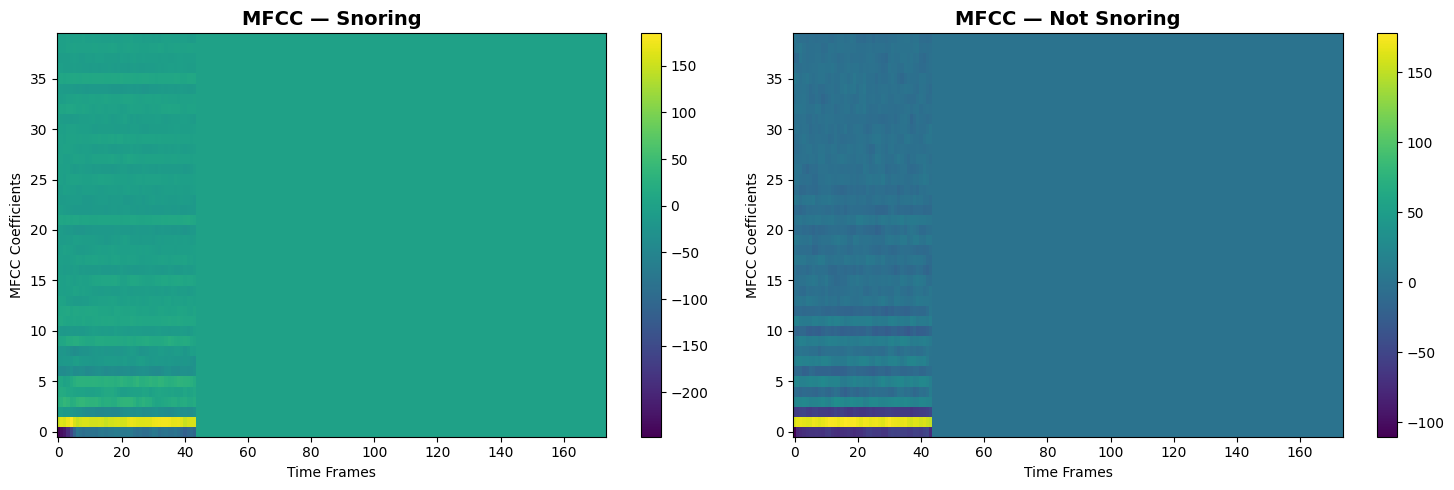

✅ MFCC visualization saved


In [ ]:
# CELL 7 — Visualize MFCC features

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Find indices for each class
snoring_idx = np.where(y == 1)[0][0]
not_snoring_idx = np.where(y == 0)[0][0]

# Plot snoring MFCC
axes[0].imshow(X[snoring_idx], aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title('MFCC — Snoring', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Time Frames')
axes[0].set_ylabel('MFCC Coefficients')
plt.colorbar(axes[0].images[0], ax=axes[0])

# Plot non-snoring MFCC
axes[1].imshow(X[not_snoring_idx], aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('MFCC — Not Snoring', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Time Frames')
axes[1].set_ylabel('MFCC Coefficients')
plt.colorbar(axes[1].images[0], ax=axes[1])

plt.tight_layout()
plt.savefig('/content/mfcc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ MFCC visualization saved")

In [ ]:
# CELL 8 — Prepare train/test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

# Reshape X for CNN input: (samples, height, width, channels)
X_reshaped = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)
print(f"X reshaped: {X_reshaped.shape}")

# Split dataset: 80% train, 10% validation, 10% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_reshaped, y, test_size=0.10, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples:       {X_test.shape[0]}")
print(f"\nTrain distribution: {np.bincount(y_train)}")
print(f"Val distribution:   {np.bincount(y_val)}")
print(f"Test distribution:  {np.bincount(y_test)}")

X reshaped: (1000, 40, 174, 1)
Training samples:   800
Validation samples: 100
Test samples:       100

Train distribution: [400 400]
Val distribution:   [50 50]
Test distribution:  [50 50]


In [ ]:
# CELL 9 — Build CNN model architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

def build_snoring_cnn(input_shape):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu',
               padding='same', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Global pooling instead of flatten
        GlobalAveragePooling2D(),

        # Dense layers
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        Dense(128, activation='relu'),
        Dropout(0.3),

        # Output
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

    return model

# Build model
input_shape = (X_train.shape[1], X_train.shape[2], 1)
model_snoring = build_snoring_cnn(input_shape)
model_snoring.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 174, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 174, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 87, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 87, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 21, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,641 (627.50 KB)

 Trainable params: 159,681 (623.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# CELL 10 — Train the model

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/best_snoring_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train
print("🚀 Training started...")
history = model_snoring.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training completed!")

🚀 Training started...
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.6087 - loss: 0.7334 - precision: 0.6085 - recall: 0.5653
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /content/best_snoring_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 286ms/step - accuracy: 0.6098 - loss: 0.7312 - precision: 0.6101 - recall: 0.5666 - val_accuracy: 0.5000 - val_loss: 0.7185 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.7785 - loss: 0.5007 - precision: 0.8173 - recall: 0.7364
Epoch 2: val_accuracy did not improve from 0.50000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.7799 - loss: 0.4974 - precision: 0.8177 - recall: 0.7387 - val_accuracy: 0.4300 - val_loss: 0.7248 - val_precision: 0.1111 - val_recall: 0.0200 - learning_rate: 0.0010
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.8999 - loss: 0.2533 - precision: 0.9011 - recall: 0.9006
Epoch 3: val_accuracy improved from 0.50000 to 0.59000, saving model to /content/best_snoring_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.9000 - loss: 0.2528 - precision: 0.9010 - recall: 0.9008 - val_accuracy: 0.5900 - val_loss: 0.6208 - val_precision: 0.5738 - val_recall: 0.7000 - learning_rate: 0.0010
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9563 - loss: 0.1387 - precision: 0.9518 - recall: 0.9634
Epoch 4: val_accuracy improved from 0.59000 to 0.84000, saving model to /content/best_snoring_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 273ms/step - accuracy: 0.9561 - loss: 0.1390 - precision: 0.9518 - recall: 0.9629 - val_accuracy: 0.8400 - val_loss: 0.4673 - val_precision: 0.7656 - val_recall: 0.9800 - learning_rate: 0.0010
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9394 - loss: 0.1549 - precision: 0.9483 - recall: 0.9296
Epoch 5: val_accuracy did not improve from 0.84000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.9398 - loss: 0.1539 - precision: 0.9488 - recall: 0.9300 - val_accuracy: 0.8000 - val_loss: 0.3977 - val_precision: 0.7143 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.9617 - loss: 0.1040 - precision: 0.9471 - recall: 0.9750
Epoch 6: val_accuracy improved from 0.84000 to 0.90000, saving model to /content/best_snoring_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 277ms/step - accuracy: 0.9618 - loss: 0.1037 - precision: 0.9477 - recall: 0.9749 - val_accuracy: 0.9000 - val_loss: 0.3152 - val_precision: 0.8333 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9675 - loss: 0.0868 - precision: 0.9578 - recall: 0.9778
Epoch 7: val_accuracy improved from 0.90000 to 0.97000, saving model to /content/best_snoring_model.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.9675 - loss: 0.0868 - precision: 0.9583 - recall: 0.9773 - val_accuracy: 0.9700 - val_loss: 0.2039 - val_precision: 0.9608 - val_recall: 0.9800 - learning_rate: 0.0010
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9675 - loss: 0.0998 - precision: 0.9589 - recall: 0.9749
Epoch 8: val_accuracy did not improve from 0.97000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.9676 - loss: 0.0995 - precision: 0.9593 - recall: 0.9747 - val_accuracy: 0.9600 - val_loss: 0.1706 - val_precision: 0.9259 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.9852 - loss: 0.0445 - precision: 0.9838 - recall: 0.9863
Epoch 9: val_accuracy did not improve from 0.97000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.9848 - loss: 0.0452 - precision: 0.9835 - recall: 0.9857 - val_accuracy: 0.9600 - val_loss: 0.1406 - val_precision: 0.9259 - val_recall: 1.0000 - learn

25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - accuracy: 0.9903 - loss: 0.0480 - precision: 0.9895 - recall: 0.9911 - val_accuracy: 0.9800 - val_loss: 0.1134 - val_precision: 0.9800 - val_recall: 0.9800 - learning_rate: 0.0010
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9856 - loss: 0.0510 - precision: 0.9915 - recall: 0.9802
Epoch 11: val_accuracy did not improve from 0.98000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 270ms/step - accuracy: 0.9853 - loss: 0.0512 - precision: 0.9911 - recall: 0.9801 - val_accuracy: 0.8200 - val_loss: 0.3266 - val_precision: 1.0000 - val_recall: 0.6400 - learning_rate: 0.0010
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.9841 - loss: 0.0463 - precision: 0.9949 - recall: 0.9732
Epoch 12: val_accuracy did not improve from 0.98000
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step - accuracy: 0.9838 - loss: 0.0469 - precision: 0.9945 - recall: 0.9730 - val_accuracy: 0.8200 - val_loss: 0.3848 - val_precision: 1.0000 - val_recall: 0.6400 - l

📊 Evaluating on test set...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

SNORING DETECTION MODEL — TEST RESULTS

Accuracy:  94.00%
F1-Score:  93.75%

Detailed Report:
              precision    recall  f1-score   support

 Not Snoring       0.91      0.98      0.94        50
     Snoring       0.98      0.90      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



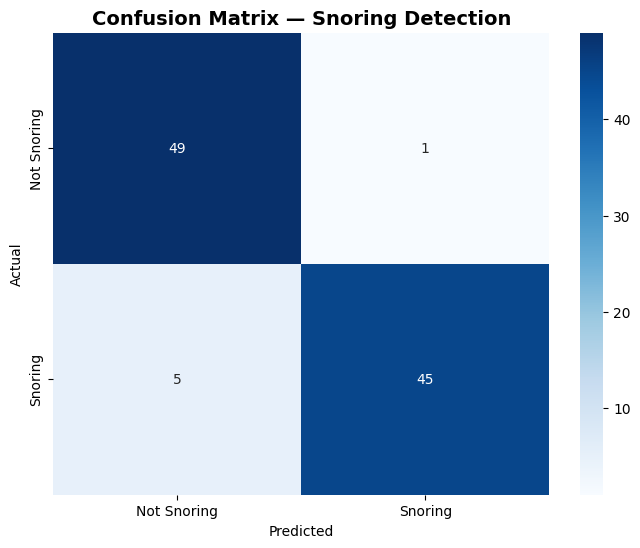

In [ ]:
# CELL 11 — Evaluate model performance

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

# Evaluate on test set
print("📊 Evaluating on test set...")
y_pred_prob = model_snoring.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Print metrics
print("\n" + "="*50)
print("SNORING DETECTION MODEL — TEST RESULTS")
print("="*50)
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred)*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Not Snoring', 'Snoring']
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Snoring', 'Snoring'],
            yticklabels=['Not Snoring', 'Snoring'])
plt.title('Confusion Matrix — Snoring Detection',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('/content/snoring_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()

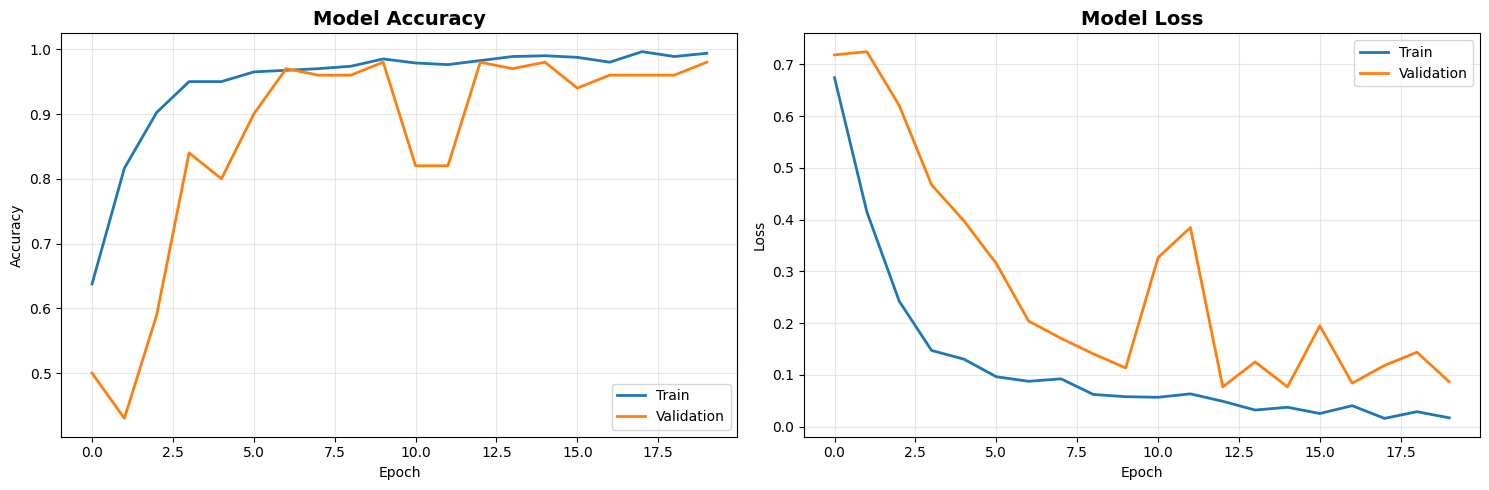

In [ ]:
# CELL 12 — Plot training curves

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/snoring_training_history.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# CELL 13 — Save model in all required formats

import json

# 1. Save full Keras model
model_snoring.save('/content/snoring_model.h5')
print("✅ Saved: snoring_model.h5")

# 2. Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model_snoring)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('/content/snoring_model.tflite', 'wb') as f:
    f.write(tflite_model)
print("✅ Saved: snoring_model.tflite")

# 3. Save model config (needed by backend)
model_config = {
    "model_type": "snoring_detection",
    "input_shape": list(input_shape),
    "mfcc_features": 40,
    "max_pad_len": 174,
    "sample_rate": 22050,
    "duration": 2.0,
    "threshold": 0.75,
    "labels": {
        "0": "not_snoring",
        "1": "snoring"
    }
}

with open('/content/snoring_model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)
print("✅ Saved: snoring_model_config.json")

# 4. Download all files
from google.colab import files
files.download('/content/snoring_model.h5')
files.download('/content/snoring_model.tflite')
files.download('/content/snoring_model_config.json')
files.download('/content/snoring_confusion_matrix.png')
files.download('/content/snoring_training_history.png')
print("\n✅ All files downloaded!")

✅ Saved: snoring_model.h5
Saved artifact at '/tmp/tmp71uz9sm9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 174, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135210279701200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135210279703696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135210279704080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135210279705040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135210279704848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135210279704656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135210279705424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135210279705232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135210279704272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135210279702544: TensorSpec(shape=(), dtype=tf.resource, na

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded!
